# Movie Recommendation System Project

## Projenin Amacı

Bu projede film verileri kullanılarak basit bir öneri sistemi geliştirilecektir.

Amaç, kullanıcıya benzer içeriklere sahip filmleri önermektir.

## Proje Yol Haritası

1. Veri setinin oluşturulması
2. Veri setinin incelenmesi
3. TF-IDF işlemi uygulanması
4. Cosine Similarity hesaplanması
5. Film öneri fonksiyonu oluşturulması
6. Öneri sonuçlarının test edilmesi
7. Sonuçların değerlendirilmesi

In [1]:
# Film datasetini oluşturuyoruz

import pandas as pd

movies = {
    "title": [
        "Batman",
        "Superman",
        "Iron Man",
        "Avengers",
        "Titanic",
        "Notebook",
        "Interstellar",
        "Inception"
    ],
    
    "description": [
        "hero action dark gotham",
        "hero flying action power",
        "technology hero action suit",
        "team hero universe action",
        "romantic ship drama love",
        "romantic drama relationship love",
        "space science future universe",
        "dream mind science thriller"
    ]
}

df = pd.DataFrame(movies)

df.head()

,title,description
0,Batman,hero action dark gotham
1,Superman,hero flying action power
2,Iron Man,technology hero action suit
3,Avengers,team hero universe action
4,Titanic,romantic ship drama love


# TF-IDF İşlemi

Bu bölümde film açıklamaları sayısal verilere dönüştürülmektedir.

In [2]:
# TF-IDF uyguluyoruz

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(df["description"])

print(tfidf_matrix.shape)

(8, 21)


# Cosine Similarity Hesaplanması

Bu bölümde filmler arasındaki benzerlik hesaplanmaktadır.

In [3]:
# Cosine similarity hesaplıyoruz

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print(cosine_sim)

[[1.         0.28676279 0.28676279 0.3033107  0.         0.
  0.         0.        ]
 [0.28676279 1.         0.28676279 0.3033107  0.         0.
  0.         0.        ]
 [0.28676279 0.28676279 1.         0.3033107  0.         0.
  0.         0.        ]
 [0.3033107  0.3033107  0.3033107  1.         0.         0.
  0.24043255 0.        ]
 [0.         0.         0.         0.         1.         0.67815901
  0.         0.        ]
 [0.         0.         0.         0.         0.67815901 1.
  0.         0.        ]
 [0.         0.         0.         0.24043255 0.         0.
  1.         0.19782726]
 [0.         0.         0.         0.         0.         0.
  0.19782726 1.        ]]


# Recommendation Fonksiyonunun Oluşturulması

Bu bölümde film öneri sistemi fonksiyonu oluşturulmaktadır.

In [4]:
# Film öneri fonksiyonu oluşturuyoruz

indices = pd.Series(df.index, index=df["title"])

def recommend(movie_name):

    idx = indices[movie_name]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:4]

    movie_indices = [i[0] for i in similarity_scores]

    return df["title"].iloc[movie_indices]

In [5]:
# Batman için önerileri alıyoruz

recommend("Batman")

3    Avengers
1    Superman
2    Iron Man
Name: title, dtype: object

# Recommendation Sonuçlarının Görselleştirilmesi

Bu bölümde film açıklama uzunlukları görselleştirilmektedir.

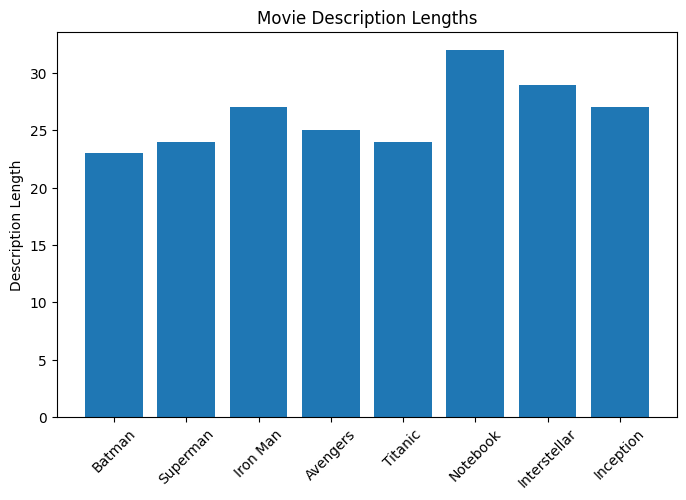

In [6]:
# Açıklama uzunluklarını görselleştiriyoruz

import matplotlib.pyplot as plt

df["length"] = df["description"].apply(len)

plt.figure(figsize=(8,5))

plt.bar(df["title"], df["length"])

plt.xticks(rotation=45)

plt.ylabel("Description Length")

plt.title("Movie Description Lengths")

plt.show()

# Similarity Heatmap

Bu bölümde filmler arasındaki benzerlikler görselleştirilmektedir.

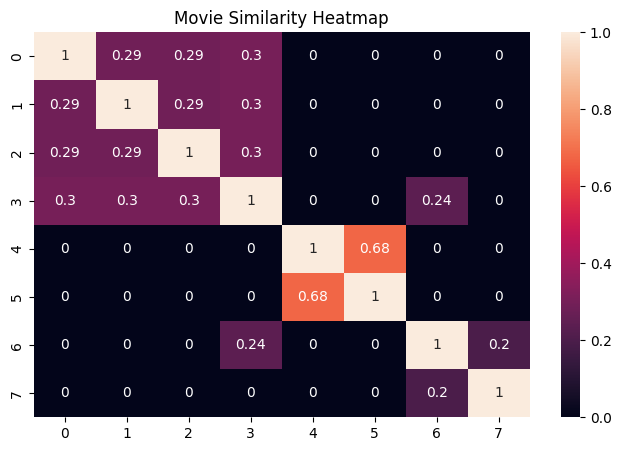

In [7]:
# Similarity heatmap oluşturuyoruz

import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(cosine_sim, annot=True)

plt.title("Movie Similarity Heatmap")

plt.show()

# Movie Recommendation System Project Sonuçları

Bu projede film açıklamaları kullanılarak basit bir öneri sistemi geliştirilmiştir.

Proje kapsamında:

- Film veri seti oluşturulmuştur.
- TF-IDF yöntemi uygulanmıştır.
- Cosine Similarity hesaplanmıştır.
- Recommendation sistemi geliştirilmiştir.

Projede:
- NLP
- TF-IDF
- Cosine Similarity

teknikleri kullanılmıştır.

Ayrıca:
- Recommendation Function
- Heatmap görselleştirmesi
- Bar plot analizi

uygulanmıştır.

Bu proje ile:
- Recommendation Systems
- NLP
- Text Mining
- Similarity Analysis

konuları uygulamalı olarak gerçekleştirilmiştir.